# Stage 6 — Clean vs Noisy Evaluation for All Models

This notebook evaluates baseline models and PhoBERT models on:

1. clean test set,
2. each Stage 4 noisy test set,
3. changed-only subset of each noisy test set.

Primary metric: **Macro-F1**.

Stage 6 does not train models. It loads previously saved Stage 2 and Stage 3 model artifacts.


## 1. Imports and project paths

In [1]:
from pathlib import Path
from datetime import datetime
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "06_noisy_evaluation_config.yaml"

from src.noisy_evaluation import (
    ModelSpec,
    load_label_mapping,
    load_noisy_files,
    prepare_clean_eval_frame,
    prepare_noisy_eval_frame,
    discover_baseline_models,
    discover_phobert_model,
    evaluate_model_on_frame,
    compute_robustness_drop,
    rank_robustness,
)

print("Project root:", PROJECT_ROOT)
print("Config path:", CONFIG_PATH)


Project root: d:\project-ml-engineering\nlp-phobert-student-feedback
Config path: d:\project-ml-engineering\nlp-phobert-student-feedback\configs\06_noisy_evaluation_config.yaml


## 2. Load config, labels, clean test, and noisy data

In [2]:
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing config: {CONFIG_PATH}")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

source_cfg = config["source"]
model_cfg = config["models"]
eval_cfg = config["evaluation"]
output_cfg = config["output"]

CLEAN_TEST_PATH = PROJECT_ROOT / source_cfg["clean_test_path"]
NOISY_DIR = PROJECT_ROOT / source_cfg["noisy_dir"]
LABEL_MAPPING_PATH = PROJECT_ROOT / source_cfg["label_mapping_path"]
NOISY_PATTERN = source_cfg.get("noisy_file_pattern", "04_test_*.csv")

TABLES_DIR = PROJECT_ROOT / output_cfg["reports_tables_dir"]
FIGURES_DIR = PROJECT_ROOT / output_cfg["reports_figures_dir"]
NOTES_DIR = PROJECT_ROOT / output_cfg["reports_notes_dir"]

for path in [TABLES_DIR, FIGURES_DIR, NOTES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if not CLEAN_TEST_PATH.exists():
    raise FileNotFoundError(f"Missing clean test file: {CLEAN_TEST_PATH}")

clean_test_df = pd.read_csv(CLEAN_TEST_PATH)
noisy_frames = load_noisy_files(NOISY_DIR, NOISY_PATTERN)
label_mapping = load_label_mapping(LABEL_MAPPING_PATH)

print("Clean test shape:", clean_test_df.shape)
print("Noisy sets:")
for noise_type, df in noisy_frames.items():
    print(f"- {noise_type}: {df.shape}")

print("\nLabel mapping:")
print(json.dumps(label_mapping, ensure_ascii=False, indent=2))

display(clean_test_df.head())
config


Clean test shape: (3166, 9)
Noisy sets:
- domain_abbreviation: (3166, 15)
- elongation: (3166, 15)
- mixed_noise: (3166, 15)
- no_accent: (3166, 15)
- teencode_colloquial: (3166, 15)
- typo: (3166, 15)

Label mapping:
{
  "sentiment": {
    "0": "negative",
    "1": "neutral",
    "2": "positive"
  },
  "topic": {
    "0": "lecturer",
    "1": "training_program",
    "2": "facility",
    "3": "others"
  }
}


,id,split,text,sentiment_label_raw,sentiment_label,topic_label_raw,topic_label,char_count,raw_word_count
0,test_0,test,nói tiếng anh lưu loát .,2,positive,0,lecturer,24,6
1,test_1,test,giáo viên rất vui tính .,2,positive,0,lecturer,24,6
2,test_2,test,cô max có tâm .,2,positive,0,lecturer,15,5
3,test_3,test,"giảng bài thu hút , dí dỏm .",2,positive,0,lecturer,28,8
4,test_4,test,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,negative,0,lecturer,79,17


{'source': {'clean_test_path': 'data/processed/test.csv',
  'noisy_dir': 'data/noisy',
  'noisy_file_pattern': '04_test_*.csv',
  'label_mapping_path': 'configs/label_mapping.json'},
 'models': {'baseline_root': 'models/baselines',
  'baseline_fallback_roots': ['models'],
  'phobert_root': 'models/phobert',
  'phobert_model_name': 'vinai/phobert-base'},
 'evaluation': {'tasks': ['sentiment', 'topic'],
  'primary_metric': 'macro_f1',
  'max_length': 128,
  'phobert_batch_size': 32,
  'run_baselines': True,
  'run_phobert': False,
  'include_changed_only': True,
  'device': 'auto'},
 'output': {'reports_tables_dir': 'reports/tables',
  'reports_figures_dir': 'reports/figures',
  'reports_notes_dir': 'reports/notes'}}

## 3. Discover available models

In [3]:
tasks = eval_cfg.get("tasks", ["sentiment", "topic"])
run_baselines = bool(eval_cfg.get("run_baselines", True))
run_phobert = bool(eval_cfg.get("run_phobert", True))

baseline_root = PROJECT_ROOT / model_cfg["baseline_root"]
fallback_roots = [
    PROJECT_ROOT / item
    for item in model_cfg.get("baseline_fallback_roots", [])
]

phobert_root = PROJECT_ROOT / model_cfg["phobert_root"]

model_specs = []

for task in tasks:
    if run_baselines:
        baseline_specs = discover_baseline_models(
            task=task,
            baseline_root=baseline_root,
            fallback_roots=fallback_roots,
        )

        if not baseline_specs:
            print(f"[WARNING] No baseline models found for task={task}")

        model_specs.extend(baseline_specs)

    if run_phobert:
        phobert_spec = discover_phobert_model(
            task=task,
            phobert_root=phobert_root,
        )

        if phobert_spec is None:
            print(f"[WARNING] No PhoBERT model found for task={task}: {phobert_root / task / 'best_model'}")
        else:
            model_specs.append(phobert_spec)

if not model_specs:
    raise FileNotFoundError("No models found. Check models/baselines and models/phobert paths.")

models_df = pd.DataFrame([
    {
        "task": spec.task,
        "model_type": spec.model_type,
        "model_name": spec.model_name,
        "path": str(spec.path),
    }
    for spec in model_specs
])

display(models_df)


,task,model_type,model_name,path
0,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...
1,sentiment,baseline,tfidf_char_svm,d:\project-ml-engineering\nlp-phobert-student-...
2,sentiment,baseline,tfidf_word_svm,d:\project-ml-engineering\nlp-phobert-student-...
3,topic,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...
4,topic,baseline,tfidf_char_svm,d:\project-ml-engineering\nlp-phobert-student-...
5,topic,baseline,tfidf_word_svm,d:\project-ml-engineering\nlp-phobert-student-...


## 4. Build evaluation datasets

In [4]:
include_changed_only = bool(eval_cfg.get("include_changed_only", True))

eval_frames_by_task = {}

for task in tasks:
    frames = []

    clean_eval = prepare_clean_eval_frame(clean_test_df, task=task)
    frames.append(clean_eval)

    for noise_type, noisy_df in noisy_frames.items():
        full_eval = prepare_noisy_eval_frame(
            noisy_df=noisy_df,
            task=task,
            evaluation_scope="full",
        )
        frames.append(full_eval)

        if include_changed_only:
            changed_eval = prepare_noisy_eval_frame(
                noisy_df=noisy_df,
                task=task,
                evaluation_scope="changed_only",
            )

            if len(changed_eval) > 0:
                frames.append(changed_eval)

    eval_frames_by_task[task] = frames

    print("\nTask:", task)
    for frame in frames:
        print(
            f"- {frame['noise_type'].iloc[0]:<24} "
            f"{frame['evaluation_scope'].iloc[0]:<13} "
            f"rows={len(frame)}"
        )



Task: sentiment
- clean                    full          rows=3166
- domain_abbreviation      full          rows=3166
- domain_abbreviation      changed_only  rows=1530
- elongation               full          rows=3166
- elongation               changed_only  rows=3164
- mixed_noise              full          rows=3166
- mixed_noise              changed_only  rows=3135
- no_accent                full          rows=3166
- no_accent                changed_only  rows=3162
- teencode_colloquial      full          rows=3166
- teencode_colloquial      changed_only  rows=1541
- typo                     full          rows=3166
- typo                     changed_only  rows=3074

Task: topic
- clean                    full          rows=3166
- domain_abbreviation      full          rows=3166
- domain_abbreviation      changed_only  rows=1530
- elongation               full          rows=3166
- elongation               changed_only  rows=3164
- mixed_noise              full          rows=3166
-

## 5. Evaluate all models

In [5]:
phobert_model_name = model_cfg.get("phobert_model_name", "vinai/phobert-base")
max_length = int(eval_cfg.get("max_length", 128))
phobert_batch_size = int(eval_cfg.get("phobert_batch_size", 32))
device = eval_cfg.get("device", "auto")

summary_rows = []
prediction_frames = []
classification_report_rows = []

for spec in model_specs:
    print("\n" + "=" * 100)
    print(f"Evaluating {spec.task} | {spec.model_type} | {spec.model_name}")
    print("Model path:", spec.path)

    task_frames = eval_frames_by_task[spec.task]

    for eval_df in task_frames:
        noise_type = str(eval_df["noise_type"].iloc[0])
        evaluation_scope = str(eval_df["evaluation_scope"].iloc[0])

        print(f"  -> noise_type={noise_type}, scope={evaluation_scope}, rows={len(eval_df)}")

        summary_row, predictions_df, report_rows = evaluate_model_on_frame(
            model_spec=spec,
            eval_df=eval_df,
            label_mapping=label_mapping,
            phobert_model_name=phobert_model_name,
            max_length=max_length,
            phobert_batch_size=phobert_batch_size,
            device=device,
        )

        summary_rows.append(summary_row)
        prediction_frames.append(predictions_df)
        classification_report_rows.extend(report_rows)

results_df = pd.DataFrame(summary_rows)
predictions_all_df = pd.concat(prediction_frames, ignore_index=True)
classification_reports_df = pd.DataFrame(classification_report_rows)

results_path = TABLES_DIR / "06_noisy_evaluation_all_models.csv"
predictions_path = TABLES_DIR / "06_model_predictions_all.csv"
classification_reports_path = TABLES_DIR / "06_classification_reports_all_models.csv"

results_df.to_csv(results_path, index=False, encoding="utf-8-sig")
predictions_all_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")
classification_reports_df.to_csv(classification_reports_path, index=False, encoding="utf-8-sig")

print("\nSaved:", results_path)
print("Saved:", predictions_path)
print("Saved:", classification_reports_path)

display(results_df.head(20))



Evaluating sentiment | baseline | majority_class
Model path: d:\project-ml-engineering\nlp-phobert-student-feedback\models\baselines\sentiment\majority_class.joblib
  -> noise_type=clean, scope=full, rows=3166
  -> noise_type=domain_abbreviation, scope=full, rows=3166
  -> noise_type=domain_abbreviation, scope=changed_only, rows=1530
  -> noise_type=elongation, scope=full, rows=3166
  -> noise_type=elongation, scope=changed_only, rows=3164
  -> noise_type=mixed_noise, scope=full, rows=3166
  -> noise_type=mixed_noise, scope=changed_only, rows=3135
  -> noise_type=no_accent, scope=full, rows=3166
  -> noise_type=no_accent, scope=changed_only, rows=3162
  -> noise_type=teencode_colloquial, scope=full, rows=3166
  -> noise_type=teencode_colloquial, scope=changed_only, rows=1541
  -> noise_type=typo, scope=full, rows=3166
  -> noise_type=typo, scope=changed_only, rows=3074

Evaluating sentiment | baseline | tfidf_char_svm
Model path: d:\project-ml-engineering\nlp-phobert-student-feedback\

,task,model_type,model_name,model_path,noise_type,evaluation_scope,num_eval_samples,accuracy,macro_f1,weighted_f1
0,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,clean,full,3166,0.502211,0.222876,0.335793
1,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,domain_abbreviation,full,3166,0.502211,0.222876,0.335793
2,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,domain_abbreviation,changed_only,1530,0.466013,0.211919,0.296270
3,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,elongation,full,3166,0.502211,0.222876,0.335793
4,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,elongation,changed_only,3164,0.502212,0.222877,0.335794
5,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,mixed_noise,full,3166,0.502211,0.222876,0.335793
6,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,mixed_noise,changed_only,3135,0.502392,0.222930,0.335995
7,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,no_accent,full,3166,0.502211,0.222876,0.335793
8,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,no_accent,changed_only,3162,0.502214,0.222877,0.335796
9,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,teencode_colloquial,full,3166,0.502211,0.222876,0.335793


## 6. Save task-specific result tables

In [6]:
for task in tasks:
    task_results = results_df[results_df["task"] == task].copy()
    task_predictions = predictions_all_df[predictions_all_df["task"] == task].copy()
    task_reports = classification_reports_df[classification_reports_df["task"] == task].copy()

    result_path = TABLES_DIR / f"06_all_models_noisy_evaluation_{task}.csv"
    prediction_path = TABLES_DIR / f"06_model_predictions_{task}.csv"
    report_path = TABLES_DIR / f"06_classification_reports_{task}.csv"

    task_results.to_csv(result_path, index=False, encoding="utf-8-sig")
    task_predictions.to_csv(prediction_path, index=False, encoding="utf-8-sig")
    task_reports.to_csv(report_path, index=False, encoding="utf-8-sig")

    print("Saved:", result_path)
    print("Saved:", prediction_path)
    print("Saved:", report_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_all_models_noisy_evaluation_sentiment.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_model_predictions_sentiment.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_classification_reports_sentiment.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_all_models_noisy_evaluation_topic.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_model_predictions_topic.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_classification_reports_topic.csv


## 7. Robustness drop tables

In [7]:
drop_df = compute_robustness_drop(results_df)

drop_path = TABLES_DIR / "06_robustness_drop_all_models.csv"
drop_df.to_csv(drop_path, index=False, encoding="utf-8-sig")
print("Saved:", drop_path)

display(drop_df.head(20))

for task in tasks:
    task_drop = drop_df[drop_df["task"] == task].copy()
    task_drop_path = TABLES_DIR / f"06_robustness_drop_{task}.csv"
    task_drop.to_csv(task_drop_path, index=False, encoding="utf-8-sig")
    print("Saved:", task_drop_path)

robustness_ranking = rank_robustness(drop_df)
ranking_path = TABLES_DIR / "06_model_robustness_ranking.csv"
robustness_ranking.to_csv(ranking_path, index=False, encoding="utf-8-sig")

print("Saved:", ranking_path)
display(robustness_ranking.round(4))


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_robustness_drop_all_models.csv


,task,model_type,model_name,noise_type,evaluation_scope,clean_macro_f1,noisy_macro_f1,absolute_macro_f1_drop,relative_macro_f1_drop_pct,clean_accuracy,noisy_accuracy,absolute_accuracy_drop
0,sentiment,baseline,majority_class,domain_abbreviation,full,0.222876,0.222876,0.000000e+00,0.000000,0.502211,0.502211,0.000000
1,sentiment,baseline,majority_class,domain_abbreviation,changed_only,0.222876,0.211919,1.095781e-02,4.916540,0.502211,0.466013,0.036198
2,sentiment,baseline,majority_class,elongation,full,0.222876,0.222876,0.000000e+00,0.000000,0.502211,0.502211,0.000000
3,sentiment,baseline,majority_class,elongation,changed_only,0.222876,0.222877,-4.128831e-07,-0.000185,0.502211,0.502212,-0.000001
4,sentiment,baseline,majority_class,mixed_noise,full,0.222876,0.222876,0.000000e+00,0.000000,0.502211,0.502211,0.000000
5,sentiment,baseline,majority_class,mixed_noise,changed_only,0.222876,0.222930,-5.356961e-05,-0.024036,0.502211,0.502392,-0.000181
6,sentiment,baseline,majority_class,no_accent,full,0.222876,0.222876,0.000000e+00,0.000000,0.502211,0.502211,0.000000
7,sentiment,baseline,majority_class,no_accent,changed_only,0.222876,0.222877,-8.262878e-07,-0.000371,0.502211,0.502214,-0.000003
8,sentiment,baseline,majority_class,teencode_colloquial,full,0.222876,0.222876,0.000000e+00,0.000000,0.502211,0.502211,0.000000
9,sentiment,baseline,majority_class,teencode_colloquial,changed_only,0.222876,0.209668,1.320851e-02,5.926386,0.502211,0.458793,0.043418


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_robustness_drop_sentiment.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_robustness_drop_topic.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_model_robustness_ranking.csv


,task,model_type,model_name,mean_absolute_macro_f1_drop,max_absolute_macro_f1_drop,mean_relative_macro_f1_drop_pct
0,sentiment,baseline,majority_class,0.0000,0.0000,0.0000
1,sentiment,baseline,tfidf_char_svm,0.0678,0.3303,9.2147
2,sentiment,baseline,tfidf_word_svm,0.0757,0.3692,10.3811
3,topic,baseline,majority_class,0.0000,0.0000,0.0000
4,topic,baseline,tfidf_char_svm,0.1061,0.4424,14.5305
5,topic,baseline,tfidf_word_svm,0.1092,0.4896,14.5460


## 8. Figures

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10748\3984522687.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  task_df


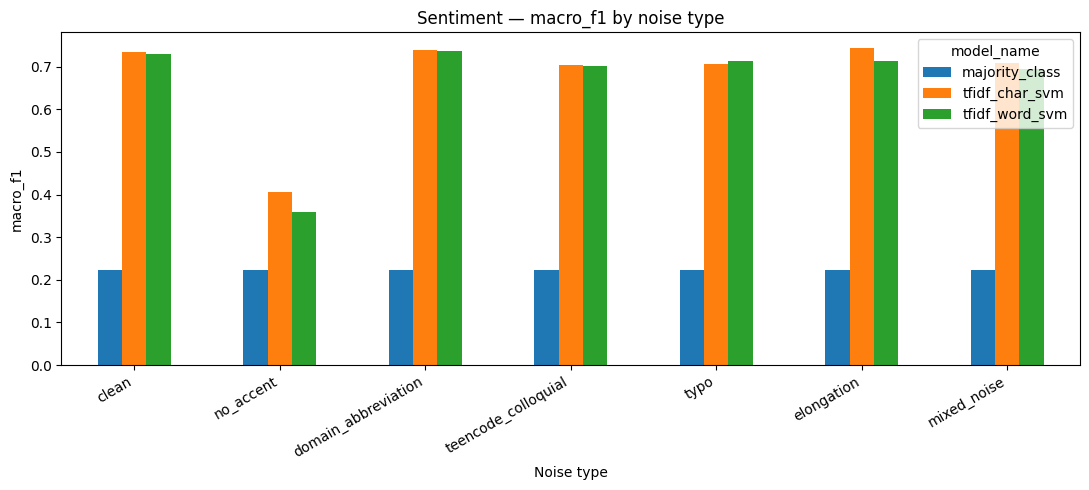

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\06_macro_f1_by_noise_type_sentiment.png


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10748\3984522687.py:64: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  task_df


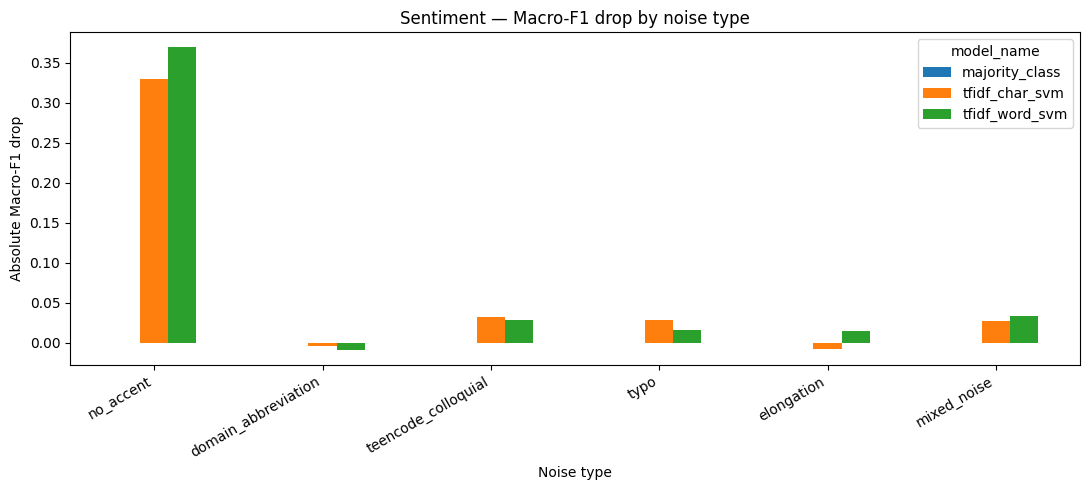

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\06_macro_f1_drop_by_noise_type_sentiment.png


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10748\3984522687.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  task_df


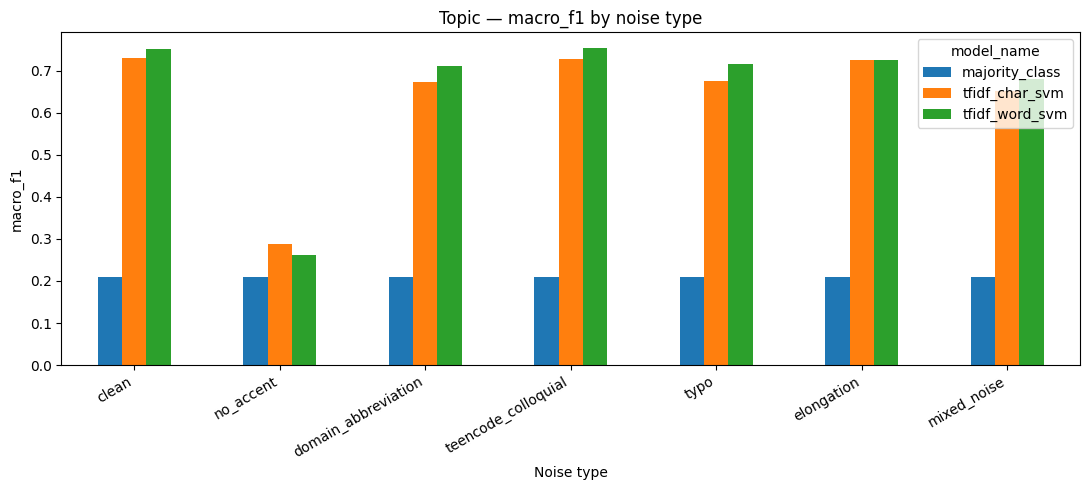

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\06_macro_f1_by_noise_type_topic.png


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10748\3984522687.py:64: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  task_df


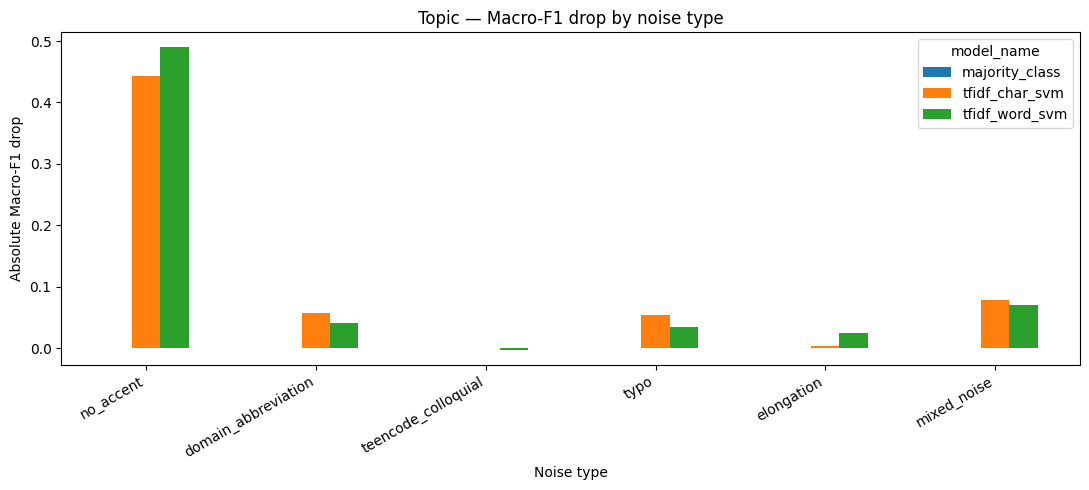

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\06_macro_f1_drop_by_noise_type_topic.png


In [8]:
def plot_metric_by_noise(task: str, metric: str = "macro_f1"):
    task_df = results_df[
        (results_df["task"] == task)
        & (results_df["evaluation_scope"] == "full")
    ].copy()

    noise_order = [
        "clean",
        "no_accent",
        "domain_abbreviation",
        "teencode_colloquial",
        "typo",
        "elongation",
        "mixed_noise",
    ]

    available_order = [item for item in noise_order if item in set(task_df["noise_type"])]
    task_df["noise_type"] = pd.Categorical(task_df["noise_type"], categories=available_order, ordered=True)

    pivot = (
        task_df
        .pivot_table(
            index="noise_type",
            columns="model_name",
            values=metric,
            aggfunc="mean",
        )
        .sort_index()
    )

    ax = pivot.plot(kind="bar", figsize=(11, 5))
    ax.set_title(f"{task.capitalize()} — {metric} by noise type")
    ax.set_xlabel("Noise type")
    ax.set_ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"06_{metric}_by_noise_type_{task}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved:", fig_path)


def plot_drop_by_noise(task: str):
    task_df = drop_df[
        (drop_df["task"] == task)
        & (drop_df["evaluation_scope"] == "full")
    ].copy()

    noise_order = [
        "no_accent",
        "domain_abbreviation",
        "teencode_colloquial",
        "typo",
        "elongation",
        "mixed_noise",
    ]

    available_order = [item for item in noise_order if item in set(task_df["noise_type"])]
    task_df["noise_type"] = pd.Categorical(task_df["noise_type"], categories=available_order, ordered=True)

    pivot = (
        task_df
        .pivot_table(
            index="noise_type",
            columns="model_name",
            values="absolute_macro_f1_drop",
            aggfunc="mean",
        )
        .sort_index()
    )

    ax = pivot.plot(kind="bar", figsize=(11, 5))
    ax.set_title(f"{task.capitalize()} — Macro-F1 drop by noise type")
    ax.set_xlabel("Noise type")
    ax.set_ylabel("Absolute Macro-F1 drop")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"06_macro_f1_drop_by_noise_type_{task}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved:", fig_path)


for task in tasks:
    plot_metric_by_noise(task, metric="macro_f1")
    plot_drop_by_noise(task)


## 9. Generate Stage 6 report

In [9]:
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return "_Empty table_"

    safe_df = df.copy()
    for col in safe_df.columns:
        if pd.api.types.is_float_dtype(safe_df[col]):
            safe_df[col] = safe_df[col].round(4)
        safe_df[col] = safe_df[col].astype(str)

    headers = safe_df.columns.tolist()
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")

    for _, row in safe_df.iterrows():
        lines.append("| " + " | ".join(row[col] for col in headers) + " |")

    return "\n".join(lines)

report_lines = []

report_lines.append("# Clean vs Noisy Evaluation Report\n")
report_lines.append(f"- Created at: `{datetime.now().isoformat(timespec='seconds')}`")
report_lines.append("- Stage: `06_noisy_evaluation_all_models`")
report_lines.append(f"- Clean test split: `{CLEAN_TEST_PATH}`")
report_lines.append(f"- Noisy data directory: `{NOISY_DIR}`")
report_lines.append("- Primary metric: `Macro-F1`")
report_lines.append("- No model is trained in this stage; all models are loaded from previous stages.\n")

report_lines.append("## Evaluation setup\n")
report_lines.append("- Clean test set is evaluated once for each model.")
report_lines.append("- Each Stage 4 noisy test set is evaluated using `noisy_text`.")
report_lines.append("- Changed-only subsets are also evaluated when `include_changed_only=true`.")
report_lines.append("- Robustness drop is computed against clean test Macro-F1 for the same task/model.\n")

report_lines.append("## Models evaluated\n")
report_lines.append(dataframe_to_markdown(models_df))
report_lines.append("\n")

report_lines.append("## Clean performance\n")
clean_perf = results_df[
    (results_df["noise_type"] == "clean")
    & (results_df["evaluation_scope"] == "full")
][[
    "task",
    "model_type",
    "model_name",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "num_eval_samples",
]].sort_values(["task", "model_type", "model_name"])
report_lines.append(dataframe_to_markdown(clean_perf))
report_lines.append("\n")

report_lines.append("## Full noisy evaluation summary\n")
full_noisy = results_df[
    (results_df["noise_type"] != "clean")
    & (results_df["evaluation_scope"] == "full")
][[
    "task",
    "model_name",
    "noise_type",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "num_eval_samples",
]]
report_lines.append(dataframe_to_markdown(full_noisy.head(80)))
report_lines.append("\n")

report_lines.append("## Robustness ranking\n")
report_lines.append(dataframe_to_markdown(robustness_ranking))
report_lines.append("\n")

report_lines.append("## Interpretation notes\n")
report_lines.append("- Positive drop means the model performs worse than on clean test data.")
report_lines.append("- Negative drop means the noisy variant happened to score higher than clean; this should be interpreted cautiously.")
report_lines.append("- Full noisy evaluation keeps all test rows. Changed-only evaluation isolates rows actually modified by Stage 4 rules.")
report_lines.append("- This stage reports quantitative robustness. Detailed error examples are left for Stage 7.\n")

report_lines.append("## Limitations\n")
report_lines.append("- Noisy data is rule-generated and not fully human-validated.")
report_lines.append("- Domain abbreviation and teencode sets include unchanged rows when no rule matched.")
report_lines.append("- Results should be interpreted together with Stage 5 tokenization analysis and Stage 7 error analysis.\n")

report_path = NOTES_DIR / "06_noisy_evaluation_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved:", report_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\06_noisy_evaluation_report.md


## 10. Final Stage 6 output check

In [10]:
expected_files = [
    TABLES_DIR / "06_noisy_evaluation_all_models.csv",
    TABLES_DIR / "06_model_predictions_all.csv",
    TABLES_DIR / "06_classification_reports_all_models.csv",
    TABLES_DIR / "06_robustness_drop_all_models.csv",
    TABLES_DIR / "06_model_robustness_ranking.csv",
    NOTES_DIR / "06_noisy_evaluation_report.md",
]

for task in tasks:
    expected_files.extend([
        TABLES_DIR / f"06_all_models_noisy_evaluation_{task}.csv",
        TABLES_DIR / f"06_model_predictions_{task}.csv",
        TABLES_DIR / f"06_classification_reports_{task}.csv",
        TABLES_DIR / f"06_robustness_drop_{task}.csv",
        FIGURES_DIR / f"06_macro_f1_by_noise_type_{task}.png",
        FIGURES_DIR / f"06_macro_f1_drop_by_noise_type_{task}.png",
    ])

print("Stage 6 output check:")

all_ok = True
for path in expected_files:
    exists = path.exists()
    all_ok = all_ok and exists
    print("[OK]     " if exists else "[MISSING]", path)

print("\nStage 6 completed:", all_ok)


Stage 6 output check:
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_noisy_evaluation_all_models.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_model_predictions_all.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_classification_reports_all_models.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_robustness_drop_all_models.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_model_robustness_ranking.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\06_noisy_evaluation_report.md
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_all_models_noisy_evaluation_sentiment.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_model_predictions_sentiment.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-fe

## What to send for review

After this notebook finishes, send:

1. `reports/tables/06_noisy_evaluation_all_models.csv`
2. `reports/tables/06_robustness_drop_all_models.csv`
3. `reports/tables/06_model_robustness_ranking.csv`
4. `reports/notes/06_noisy_evaluation_report.md`
5. Final output check text

If the result files are large, send the three summary CSV files and the markdown report first.
